# Gas Meter OCR Pipeline — Visual Walkthrough

**Goal:** Extract the first 5 digits (white on black background) from a SAMGAZ G4 gas meter.

This notebook walks through each stage of the OpenCV-only pipeline, showing the image transformation at every step.

**Pipeline:**
```
Original Image → Preprocess → Find Counter Window → Separate Black/Red → Segment Digits → Recognize → Reading
```

In [57]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
from src.config import load_config

config = load_config("config.json")

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["image.cmap"] = "gray"

IMAGE_PATH = "images/local_image.jpg"

## Stage 0: Original Image

The raw input — a photo of the SAMGAZ G4 gas meter taken with a fixed-position camera.

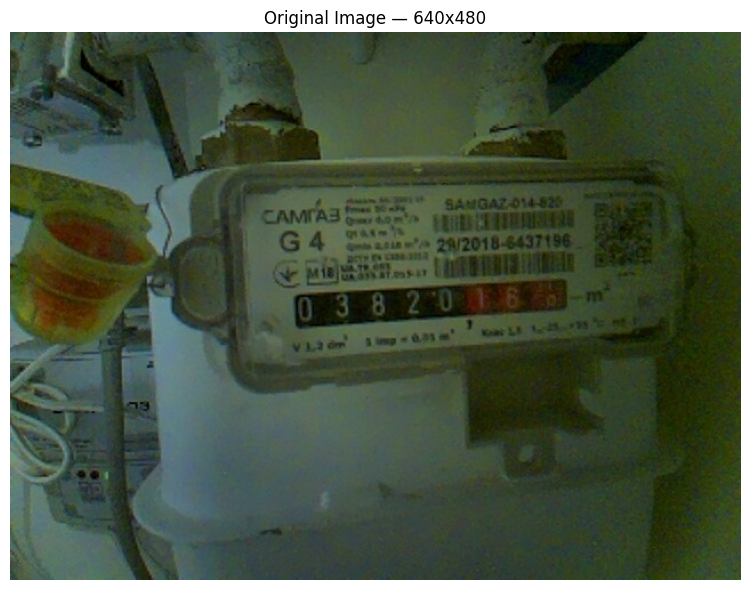

In [58]:
original = cv2.imread(IMAGE_PATH)
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(original_rgb)
ax.set_title(f"Original Image — {original.shape[1]}x{original.shape[0]}")
ax.axis("off")

plt.tight_layout()
plt.show()

## Stage 1: Preprocessing

Three operations to normalize the image for consistent processing:

1. **Resize** to 640px width — saves memory on RPi (230KB vs 6MB)
2. **CLAHE** (Contrast Limited Adaptive Histogram Equalization) — fixes uneven lighting
3. **Gaussian blur** (3x3) — reduces camera sensor noise

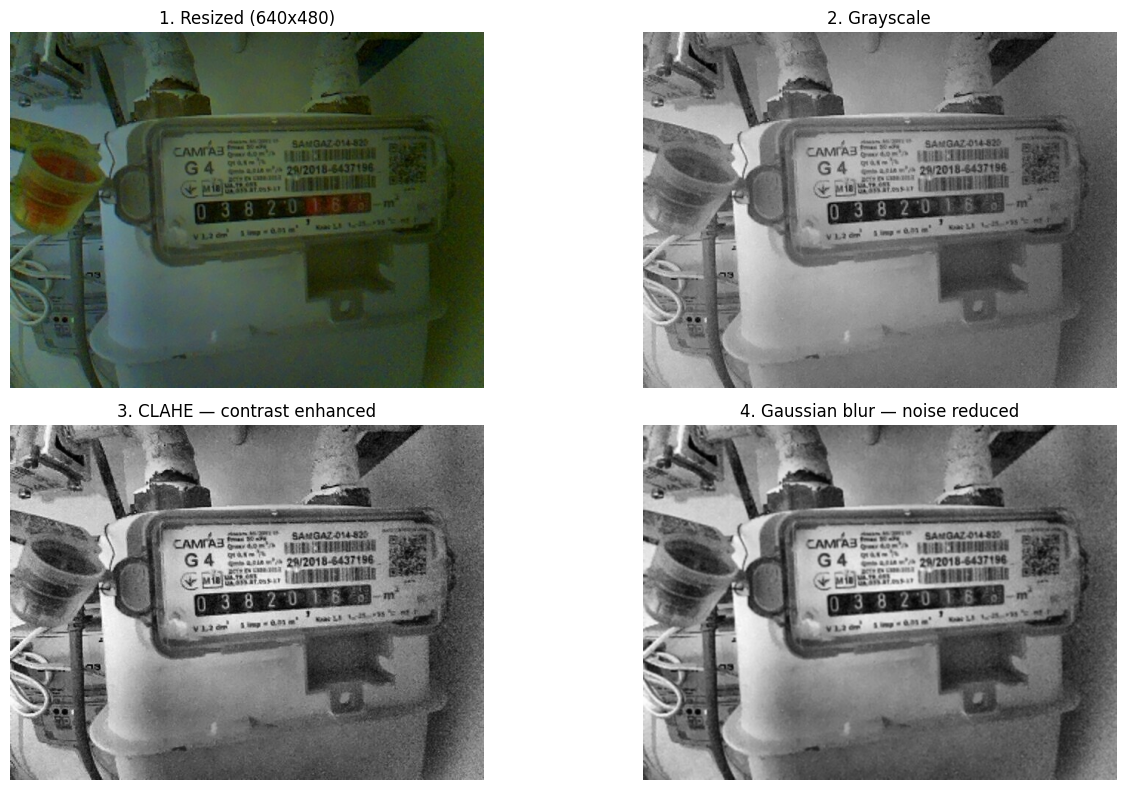

In [59]:
# Step-by-step preprocessing to show each transformation
WORKING_WIDTH = 640

h, w = original.shape[:2]
scale = WORKING_WIDTH / w
new_h = int(h * scale)

# 1. Resize
resized = cv2.resize(original, (WORKING_WIDTH, new_h), interpolation=cv2.INTER_AREA)
resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

# 2. Grayscale
gray_raw = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

# 3. CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
gray_clahe = clahe.apply(gray_raw)

# 4. Gaussian blur
gray_final = cv2.GaussianBlur(gray_clahe, (3, 3), 0)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].imshow(resized_rgb)
axes[0, 0].set_title(f"1. Resized ({WORKING_WIDTH}x{new_h})")

axes[0, 1].imshow(gray_raw, cmap="gray")
axes[0, 1].set_title("2. Grayscale")

axes[1, 0].imshow(gray_clahe, cmap="gray")
axes[1, 0].set_title("3. CLAHE — contrast enhanced")

axes[1, 1].imshow(gray_final, cmap="gray")
axes[1, 1].set_title("4. Gaussian blur — noise reduced")

for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Keep color copy for later (Stage 3 needs it)
color = resized.copy()
gray = gray_final

## Stage 2: Counter Window Detection

Find the dark rectangular counter display in the meter image.

**Method:** Threshold at brightness=80 (dark pixels) → morphological closing (connect nearby dark areas) → find contours → pick the largest rectangle with aspect ratio 2:1–8:1.

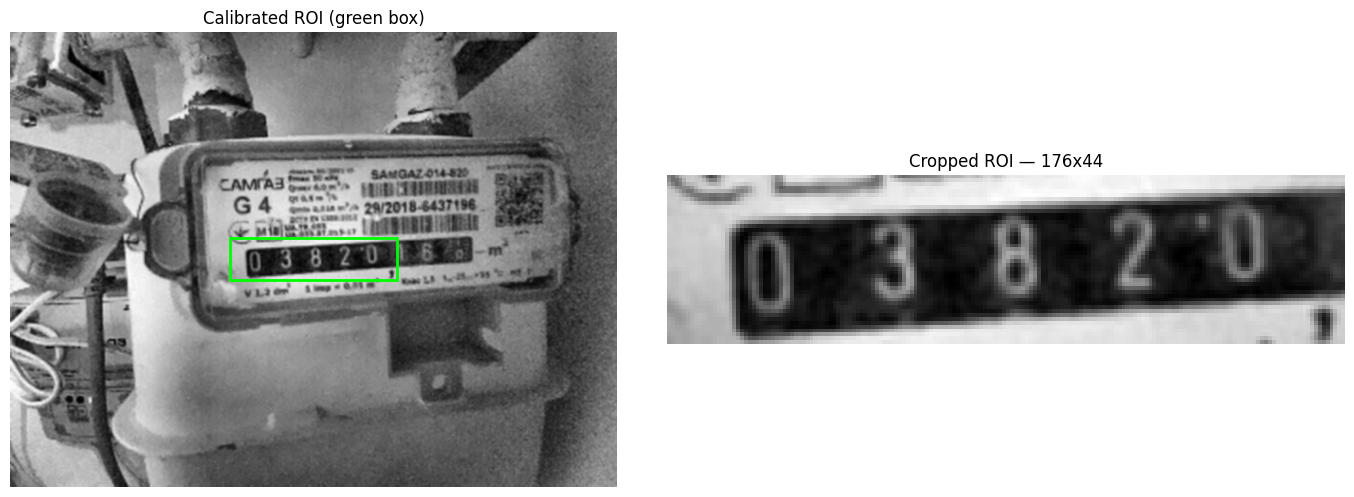

In [60]:
# First, use the calibrated ROI to narrow the search area
roi = config.roi

img_h, img_w = gray.shape
x = int(roi.x_norm * img_w)
y = int(roi.y_norm * img_h)
rw = int(roi.w_norm * img_w)
rh = int(roi.h_norm * img_h)
margin_x, margin_y = int(rw * 0.1), int(rh * 0.1)
x, y = max(0, x - margin_x), max(0, y - margin_y)
rw = min(img_w - x, rw + 2 * margin_x)
rh = min(img_h - y, rh + 2 * margin_y)

gray_crop = gray[y : y + rh, x : x + rw]
color_crop = color[y : y + rh, x : x + rw]

# Show the ROI on the full image
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(gray, cmap="gray")
rect = patches.Rectangle((x, y), rw, rh, linewidth=2, edgecolor="lime", facecolor="none")
axes[0].add_patch(rect)
axes[0].set_title("Calibrated ROI (green box)")
axes[0].axis("off")

axes[1].imshow(gray_crop, cmap="gray")
axes[1].set_title(f"Cropped ROI — {gray_crop.shape[1]}x{gray_crop.shape[0]}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

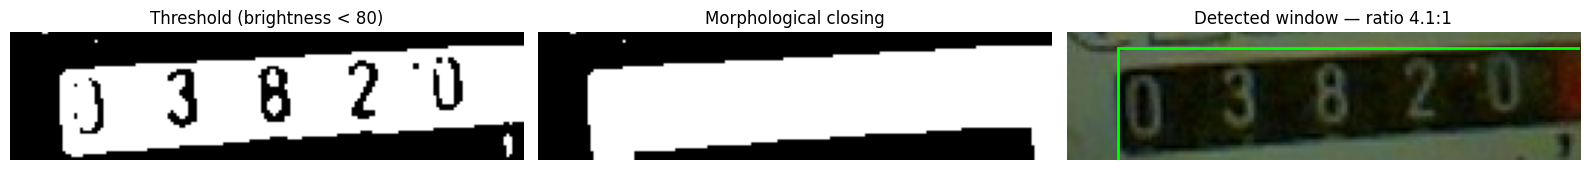

Counter window: 159x39 pixels, aspect ratio 4.1:1


In [61]:
# Dynamic detection within the ROI: threshold + morphology + contour
_, thresh = cv2.threshold(gray_crop, 80, 255, cv2.THRESH_BINARY_INV)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 5))
closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Find the best rectangle
best = None
best_area = 0
for c in contours:
    bx, by, bw, bh = cv2.boundingRect(c)
    if bh == 0:
        continue
    ratio = bw / bh
    area = bw * bh
    if 2.0 < ratio < 8.0 and area > best_area and area > 2000:
        best = (bx, by, bw, bh)
        best_area = area

dx, dy, dw, dh = best

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].imshow(thresh, cmap="gray")
axes[0].set_title("Threshold (brightness < 80)")

axes[1].imshow(closed, cmap="gray")
axes[1].set_title("Morphological closing")

# Draw detected rectangle on color crop
crop_rgb = cv2.cvtColor(color_crop, cv2.COLOR_BGR2RGB)
axes[2].imshow(crop_rgb)
rect = patches.Rectangle((dx, dy), dw, dh, linewidth=2, edgecolor="lime", facecolor="none")
axes[2].add_patch(rect)
axes[2].set_title(f"Detected window — ratio {dw/dh:.1f}:1")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Extract the counter window
window_gray = gray_crop[dy : dy + dh, dx : dx + dw]
window_color = color_crop[dy : dy + dh, dx : dx + dw]
print(f"Counter window: {dw}x{dh} pixels, aspect ratio {dw/dh:.1f}:1")

In [68]:
import  src.roi_detector
# Remove the perspective
src.roi_detector.deskew

AttributeError: module 'src.roi_detector' has no attribute 'deskew'

## Stage 3: Black / Red Separation

The counter has **8 digit wheels**: 5 on black background (integer part) and 3 on red background (decimal part). We only need the first 5.

**Method:** Convert to HSV color space → create a red mask (hue near 0 and 180) → find the leftmost column where red pixels appear → crop everything to the left of that boundary.

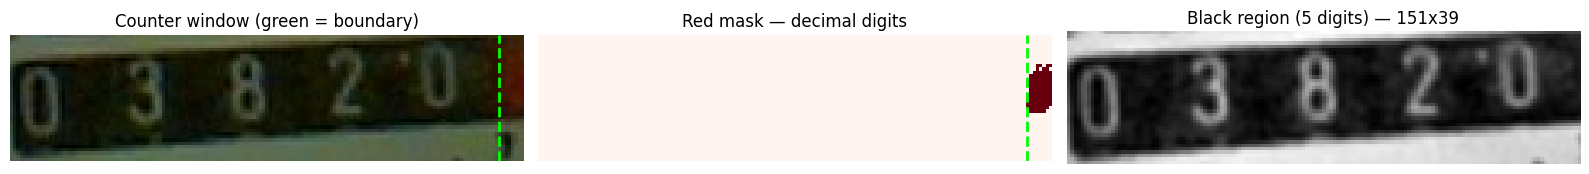

Red boundary at column 151 / 159 (95%)


In [62]:
# HSV red detection
hsv = cv2.cvtColor(window_color, cv2.COLOR_BGR2HSV)
mask1 = cv2.inRange(hsv, np.array([0, 40, 40]), np.array([10, 255, 255]))
mask2 = cv2.inRange(hsv, np.array([160, 40, 40]), np.array([180, 255, 255]))
red_mask = mask1 | mask2

# Find where red begins
col_sums = np.sum(red_mask > 0, axis=0)
red_cols = np.where(col_sums > window_color.shape[0] * 0.1)[0]
boundary = int(red_cols[0]) if len(red_cols) > 0 else int(window_color.shape[1] * 0.625)

# Crop to black region only
black_region = window_gray[:, :boundary]



fig, axes = plt.subplots(1, 3, figsize=(16, 4))

window_rgb = cv2.cvtColor(window_color, cv2.COLOR_BGR2RGB)
axes[0].imshow(window_rgb)
axes[0].axvline(x=boundary, color="lime", linewidth=2, linestyle="--")
axes[0].set_title("Counter window (green = boundary)")

axes[1].imshow(red_mask, cmap="Reds")
axes[1].axvline(x=boundary, color="lime", linewidth=2, linestyle="--")
axes[1].set_title("Red mask — decimal digits")

axes[2].imshow(black_region, cmap="gray")
axes[2].set_title(f"Black region (5 digits) — {black_region.shape[1]}x{black_region.shape[0]}")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Red boundary at column {boundary} / {window_color.shape[1]} ({boundary/window_color.shape[1]:.0%})")

## Stage 4: Digit Segmentation

Split the black region into 5 individual digit images.

**Why fixed-width slicing?** Mechanical counter digits are stamped onto wheels — they're *guaranteed* to be uniformly spaced. Contour-based segmentation would be fragile here (digits like "0" and "8" have enclosed holes that confuse contour detection).

**Steps per digit slot:**
1. Slice at equal width intervals (with small margin to avoid divider lines)
2. **Adaptive threshold** — converts to binary (much better than Otsu for low-contrast images)
3. Crop to bounding box of white pixels
4. Resize to standard 40x60 template size

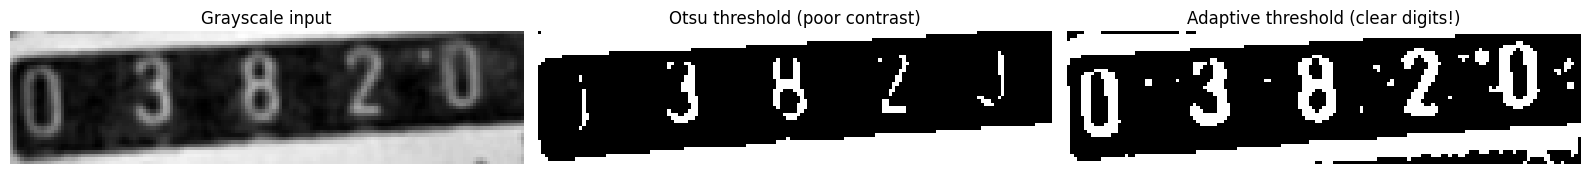

In [63]:
# Show the adaptive threshold vs Otsu comparison
_, otsu_result = cv2.threshold(black_region, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
adaptive_result = cv2.adaptiveThreshold(
    black_region, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 21, -5
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].imshow(black_region, cmap="gray")
axes[0].set_title("Grayscale input")
axes[1].imshow(otsu_result, cmap="gray")
axes[1].set_title("Otsu threshold (poor contrast)")
axes[2].imshow(adaptive_result, cmap="gray")
axes[2].set_title("Adaptive threshold (clear digits!)")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

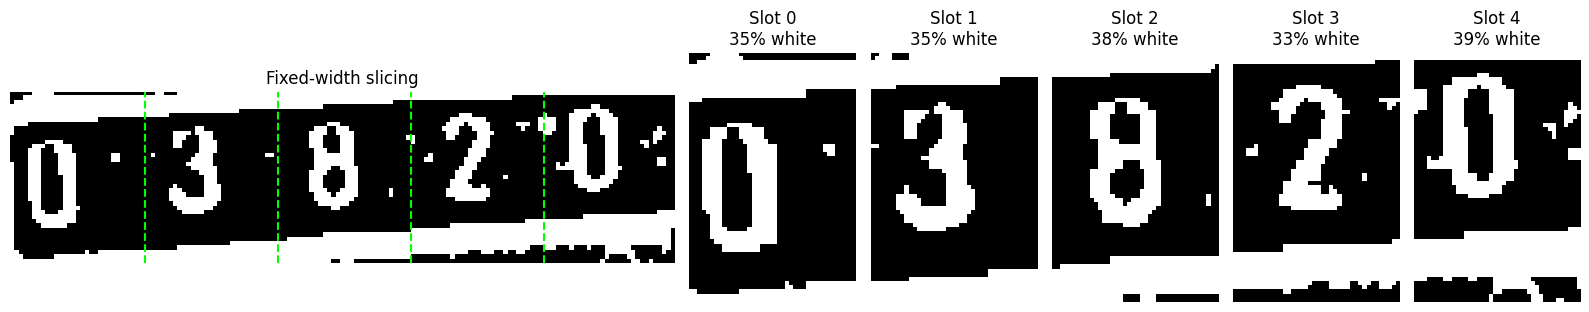

Each digit: 40x60 pixels, binary (0 or 255)


In [48]:
# Segment into 5 individual digits
from src.segmenter import segment_digits

digit_images = segment_digits(black_region, num_digits=5, template_size=(40, 60))

# Show slicing on the binary image, then each extracted digit
fig, axes = plt.subplots(1, 6, figsize=(16, 4), gridspec_kw={"width_ratios": [4, 1, 1, 1, 1, 1]})

# Left panel: binary region with slot boundaries
bh, bw = black_region.shape
slot_width = bw / 5
margin = int(slot_width * 0.08)

axes[0].imshow(adaptive_result, cmap="gray")
for i in range(1, 5):
    axes[0].axvline(x=i * slot_width, color="lime", linewidth=1.5, linestyle="--")
axes[0].set_title("Fixed-width slicing")
axes[0].axis("off")

# Right panels: individual digits
for i, d in enumerate(digit_images):
    axes[i + 1].imshow(d, cmap="gray")
    white_pct = np.sum(d == 255) / d.size * 100
    axes[i + 1].set_title(f"Slot {i}\n{white_pct:.0f}% white")
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

print(f"Each digit: {digit_images[0].shape[1]}x{digit_images[0].shape[0]} pixels, binary (0 or 255)")

## Stage 5: Template Matching — Recognition

Each digit is compared against 10 templates (0-9) using **hybrid scoring**:

$$\text{score} = 0.6 \times \text{correlation} + 0.4 \times \text{pixel overlap (IoU)}$$

- **Correlation** (`cv2.matchTemplate` with `TM_CCOEFF_NORMED`): measures shape similarity
- **Pixel IoU** (Intersection over Union of white pixels): catches density differences (e.g., "1" vs "7")

The recognized digit = the template with the highest score. Confidence = gap between best and second-best.

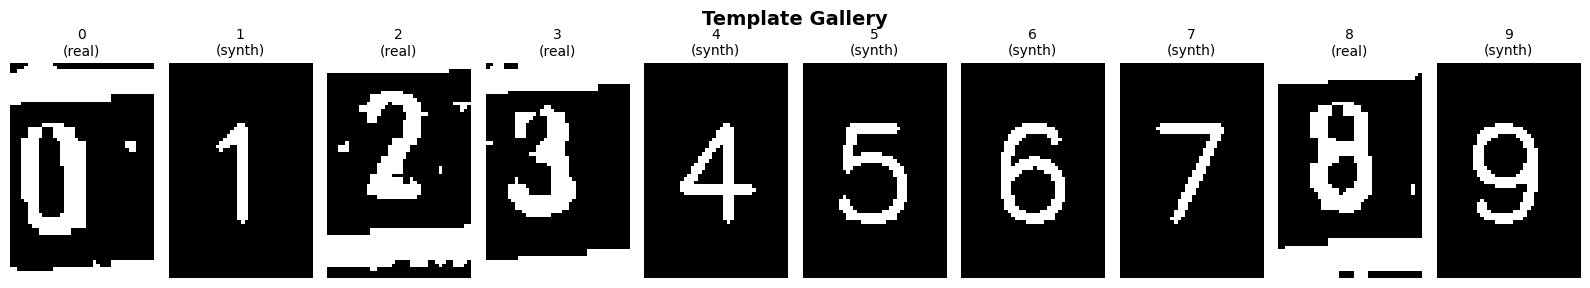

In [64]:
# Load templates and show them
from src.recognizer import load_templates

templates = load_templates("templates/templates.npz")

fig, axes = plt.subplots(1, 10, figsize=(16, 3))
for digit in range(10):
    axes[digit].imshow(templates[digit], cmap="gray")
    # Mark real vs synthetic
    source = "real" if digit in {0, 2, 3, 8} else "synth"
    axes[digit].set_title(f"{digit}\n({source})", fontsize=10)
    axes[digit].axis("off")

plt.suptitle("Template Gallery", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

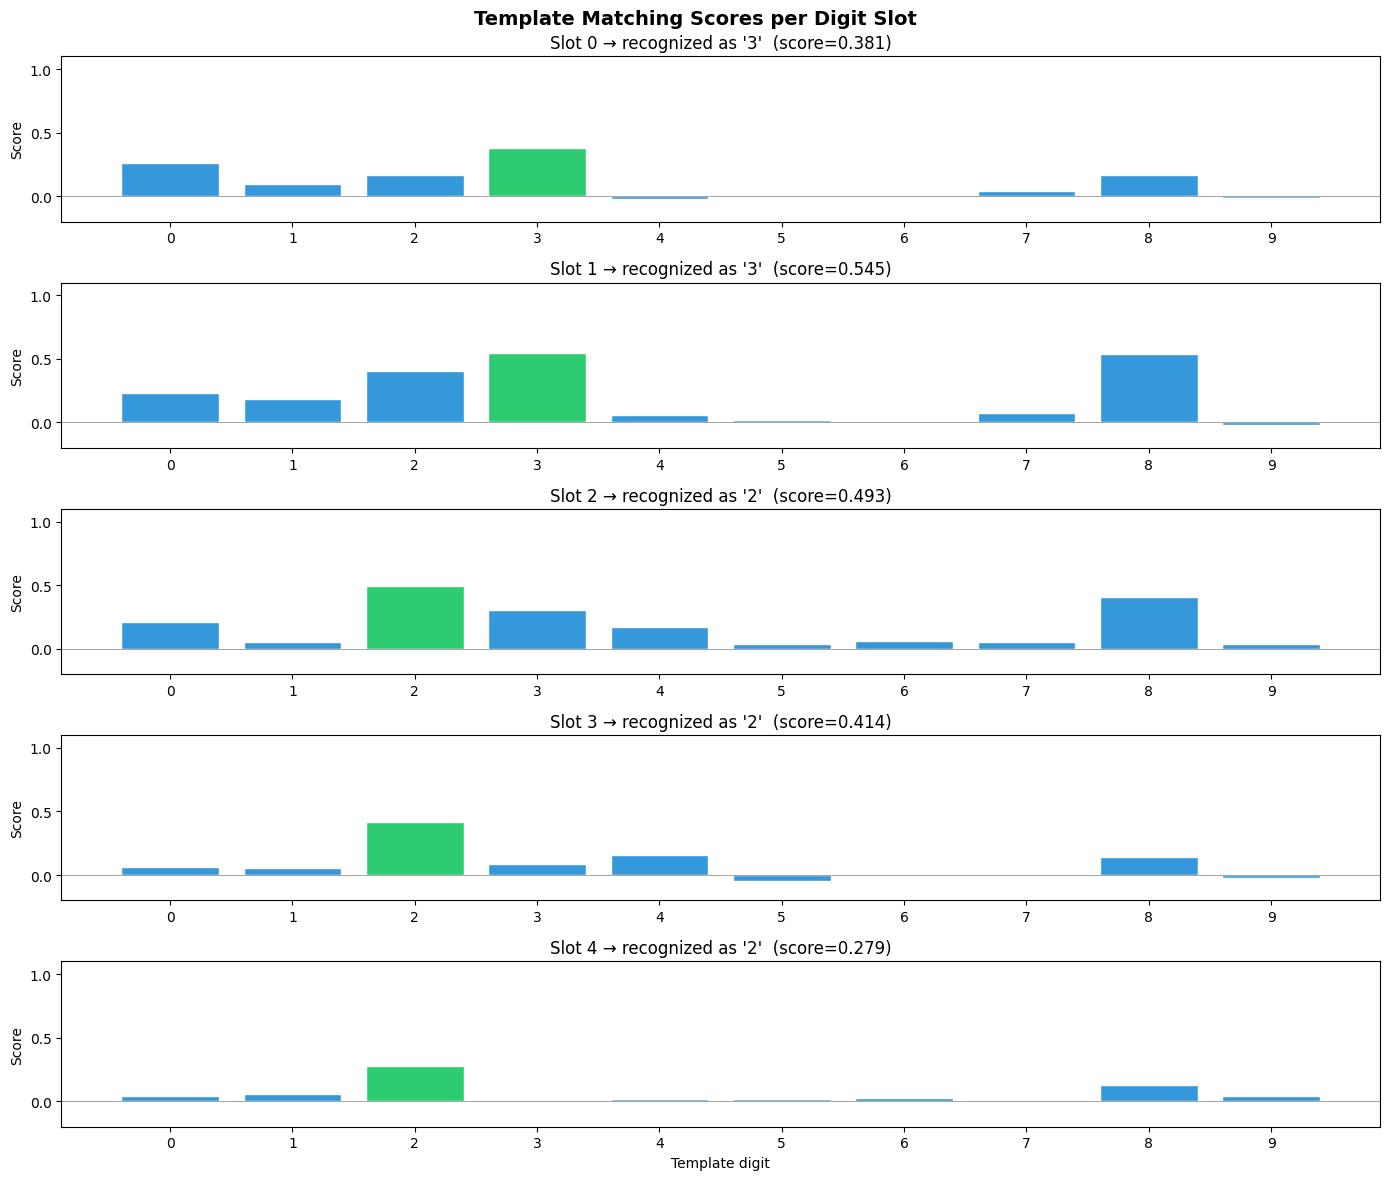

In [45]:
# Detailed matching for each digit — show scores against all templates
fig, axes = plt.subplots(5, 1, figsize=(14, 12))

for idx, digit_img in enumerate(digit_images):
    scores = []
    for t_digit, tmpl in sorted(templates.items()):
        img = digit_img if digit_img.shape == tmpl.shape else cv2.resize(
            digit_img, (tmpl.shape[1], tmpl.shape[0])
        )
        # Correlation
        result = cv2.matchTemplate(
            img.astype(np.float32), tmpl.astype(np.float32), cv2.TM_CCOEFF_NORMED
        )
        correlation = float(result[0, 0])
        # Pixel IoU
        img_w = img > 127
        tmpl_w = tmpl > 127
        inter = np.sum(img_w & tmpl_w)
        union = np.sum(img_w | tmpl_w)
        iou = float(inter / union) if union > 0 else 0.0
        combined = 0.6 * correlation + 0.4 * iou
        scores.append(combined)

    best_digit = np.argmax(scores)
    colors = ["#2ecc71" if i == best_digit else "#3498db" for i in range(10)]

    axes[idx].bar(range(10), scores, color=colors, edgecolor="white")
    axes[idx].set_xticks(range(10))
    axes[idx].set_ylabel("Score")
    axes[idx].set_title(f"Slot {idx} → recognized as '{best_digit}'  (score={scores[best_digit]:.3f})")
    axes[idx].set_ylim(-0.2, 1.1)
    axes[idx].axhline(y=0, color="gray", linewidth=0.5)

plt.xlabel("Template digit")
plt.suptitle("Template Matching Scores per Digit Slot", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Stage 6: Final Result

Run the complete pipeline end-to-end and show the result overlaid on the original image.

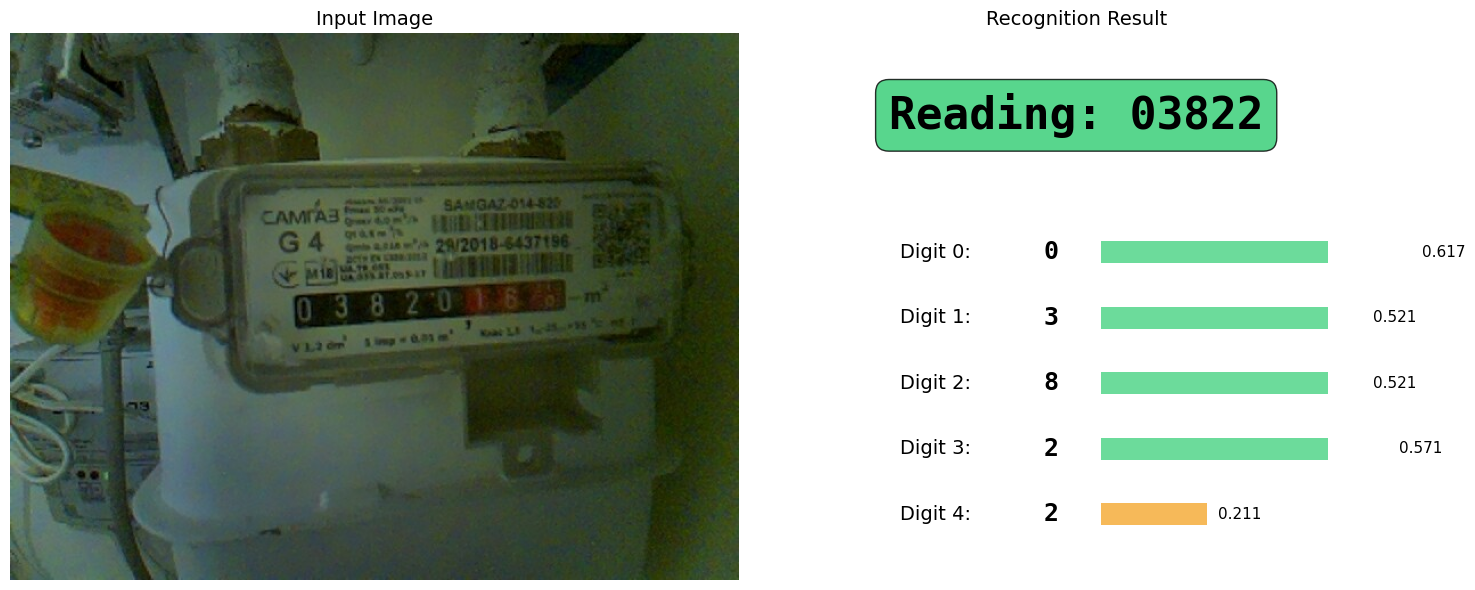

In [65]:
from src.pipeline import read_meter

reading = read_meter(IMAGE_PATH)

# Display side by side: original image + recognized digits + confidence
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [2, 1]})

# Left: original with annotated reading
axes[0].imshow(original_rgb)
axes[0].set_title("Input Image", fontsize=14)
axes[0].axis("off")

# Right: result summary
axes[1].axis("off")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

# Big reading
axes[1].text(
    0.5, 0.85, f"Reading: {reading.digits}",
    fontsize=32, fontweight="bold", ha="center", va="center",
    fontfamily="monospace",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#2ecc71", alpha=0.8),
)

# Per-digit details
for i, (d, c, t) in enumerate(zip(reading.digits, reading.confidence, reading.transitioning)):
    y_pos = 0.6 - i * 0.12
    color = "#e74c3c" if t else "#2ecc71" if c > 0.5 else "#f39c12"
    status = " TRANS" if t else ""
    axes[1].text(0.15, y_pos, f"Digit {i}:", fontsize=14, ha="left", va="center")
    axes[1].text(0.45, y_pos, f"{d}", fontsize=18, fontweight="bold",
                 ha="center", va="center", fontfamily="monospace")
    # Confidence bar
    axes[1].barh(y_pos, c, height=0.04, left=0.55, color=color, alpha=0.7)
    axes[1].text(0.55 + c + 0.02, y_pos, f"{c:.3f}{status}", fontsize=11, va="center")

axes[1].set_title("Recognition Result", fontsize=14)

plt.tight_layout()
plt.show()

## Performance Profile

How much memory and time does each stage use? This matters on RPi Zero W2 (512 MB RAM).

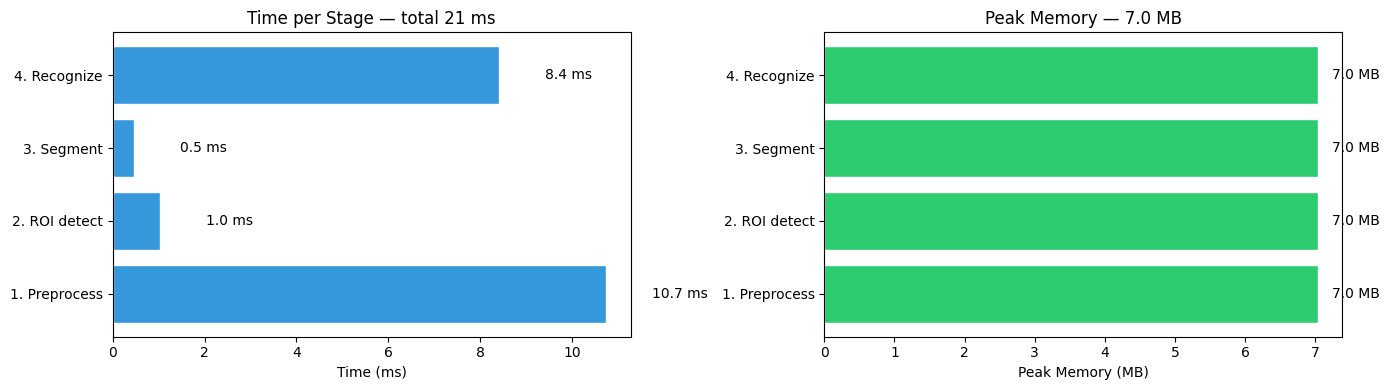


Total pipeline: 21 ms, peak 7.0 MB
RPi Zero W2 estimate: ~0-0 ms (ARM is ~10-15x slower)


In [13]:
import tracemalloc
import time

from src.config import load_config
from src.preprocessing import load_and_prepare
from src.roi_detector import find_counter_window
from src.segmenter import segment_digits
from src.recognizer import load_templates, recognize_all

config = load_config("config.json")
tmpls = load_templates("templates/templates.npz")

stages = []

tracemalloc.start()

t0 = time.perf_counter()
gray, color = load_and_prepare(IMAGE_PATH, config.working_width)
t1 = time.perf_counter()
_, peak1 = tracemalloc.get_traced_memory()
stages.append(("1. Preprocess", t1 - t0, peak1))

black_region = find_counter_window(gray, color, config)
t2 = time.perf_counter()
_, peak2 = tracemalloc.get_traced_memory()
stages.append(("2. ROI detect", t2 - t1, peak2))

digit_imgs = segment_digits(black_region, config.num_digits, config.template_size)
t3 = time.perf_counter()
_, peak3 = tracemalloc.get_traced_memory()
stages.append(("3. Segment", t3 - t2, peak3))

result = recognize_all(digit_imgs, tmpls)
t4 = time.perf_counter()
_, peak4 = tracemalloc.get_traced_memory()
stages.append(("4. Recognize", t4 - t3, peak4))

tracemalloc.stop()

total_time = t4 - t0

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

names = [s[0] for s in stages]
times = [s[1] * 1000 for s in stages]  # ms
mems = [s[2] / 1024 / 1024 for s in stages]  # MB

ax1.barh(names, times, color="#3498db", edgecolor="white")
ax1.set_xlabel("Time (ms)")
ax1.set_title(f"Time per Stage — total {total_time*1000:.0f} ms")
for i, v in enumerate(times):
    ax1.text(v + 1, i, f"{v:.1f} ms", va="center")

ax2.barh(names, mems, color="#2ecc71", edgecolor="white")
ax2.set_xlabel("Peak Memory (MB)")
ax2.set_title(f"Peak Memory — {max(mems):.1f} MB")
for i, v in enumerate(mems):
    ax2.text(v + 0.2, i, f"{v:.1f} MB", va="center")

plt.tight_layout()
plt.show()

print(f"\nTotal pipeline: {total_time*1000:.0f} ms, peak {max(mems):.1f} MB")
print(f"RPi Zero W2 estimate: ~{total_time*10:.0f}-{total_time*15:.0f} ms (ARM is ~10-15x slower)")

## Summary

| Stage | What it does | Key technique |
|-------|-------------|---------------|
| **Preprocess** | Normalize image | CLAHE + Gaussian blur |
| **ROI detect** | Find counter window | Threshold + morphology + contour filtering |
| **Black/Red** | Isolate 5 integer digits | HSV red mask |
| **Segment** | Split into individual digits | Fixed-width slicing + adaptive threshold |
| **Recognize** | Match each digit to 0-9 | Template correlation + pixel IoU |

**Key design decisions:**
- Adaptive threshold >> Otsu for low-contrast meter images
- Fixed-width slicing >> contour segmentation for uniform mechanical counters
- Real templates from the actual meter >> synthetic font templates
- No ML models needed — OpenCV only, fits in 17 MB RAM